# EDA Mini Challenge

This notebook demonstrates an independent Exploratory Data Analysis (EDA) workflow using the Titanic dataset.

The objective is to analyze the dataset step by step without relying on detailed instructions. The analysis includes dataset understanding, data inspection, data quality checks, numerical and categorical analysis, outlier detection, distribution analysis, correlation analysis, visualization, pattern identification, business insights, and recommendations for the next preprocessing stage.

## AI/ML Relevance

Independent EDA is important for an AI/ML Engineer because real-world datasets may not always come with detailed instructions. The ability to understand and investigate a dataset independently helps in making better decisions before building a Machine Learning model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Dataset Understanding

### Concept

Dataset understanding is the first step in EDA. It helps us identify the size, features, target variable, and general structure of the dataset.

### Example

In the Titanic dataset, each row represents a passenger, while the columns contain information such as age, sex, passenger class, fare, and survival status.

### Interpretation

Understanding the dataset helps us identify what information is available and what type of analysis can be performed.

### Insight

The Titanic dataset contains passenger information that can be used to analyze factors associated with survival.

### AI/ML Relevance

Dataset understanding helps identify the target variable and determine the type of Machine Learning problem.

In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
display(df.head())

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First Five Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Structure and Data Types

### Concept

Data inspection helps us understand the structure and data type of each column.

### Example

Columns such as `Age` and `Fare` are numerical, while `Sex` and `Embarked` are categorical.

### Interpretation

Different data types require different analysis and preprocessing methods.

### Insight

Some columns may also represent identifiers or text information rather than direct numerical features.

### AI/ML Relevance

Correctly identifying data types is important for feature selection, encoding, transformation, and model preparation.

In [3]:
print(df.info())

print("\nData Types:")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin     

## 3. Missing Values

### Concept

Missing values occur when information is unavailable for certain observations.

### Example

A passenger may have a missing age or cabin value.

### Interpretation

The number and percentage of missing values help us understand the seriousness of the problem.

### Insight

Different columns may require different missing-value treatment methods.

### AI/ML Relevance

Missing values must be investigated before model training because many Machine Learning algorithms cannot directly handle incomplete data.

In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

print(missing_summary[missing_summary["Missing Count"] > 0].round(2))

          Missing Count  Missing Percentage
Age                 177               19.87
Cabin               687               77.10
Embarked              2                0.22


## 4. Duplicate Records

### Concept

Duplicate records are observations that appear more than once in the dataset.

### Example

If the same complete passenger record is repeated multiple times, it may be considered a duplicate.

### Interpretation

Completely duplicated rows should be identified before preprocessing.

### Insight

Similar passengers are not necessarily duplicates. Only repeated records should be treated as actual duplicates.

### AI/ML Relevance

Duplicate records can give repeated observations extra influence during model training and may create bias.

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


## 5. Numerical Feature Analysis

### Concept

Numerical feature analysis summarizes continuous and discrete numerical variables.

### Example

For `Age` and `Fare`, we can calculate the mean, median, minimum, maximum, and standard deviation.

### Interpretation

These statistics help us understand the center and spread of the data.

### Insight

Numerical variables may have different ranges and distributions.

### AI/ML Relevance

Numerical analysis helps identify scaling requirements, skewness, unusual values, and potential feature transformations.

In [6]:
numerical_cols = df.select_dtypes(include="number").columns

print("Numerical Columns:")
print(numerical_cols.tolist())

print("\nStatistical Summary:")
print(df[numerical_cols].describe().round(2))

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Statistical Summary:
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


## 6. Categorical Feature Analysis

### Concept

Categorical analysis examines the unique categories and frequencies of non-numerical variables.

### Example

The `Sex` column contains categories such as male and female.

### Interpretation

Category counts help us understand how observations are distributed across different groups.

### Insight

Some categorical features may have a small number of categories, while others may have high cardinality.

### AI/ML Relevance

Categorical variables usually require encoding before being used in many Machine Learning models.

In [8]:
categorical_cols = df.select_dtypes(include="str").columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


## 7. Outlier Detection

### Concept

An outlier is an observation that is unusually far from most other observations.

### Example

An extremely high ticket fare may be identified as a potential outlier.

### Interpretation

Potential outliers should be investigated rather than automatically removed.

### Insight

An unusual observation may be a genuine passenger record and can still contain useful information.

### AI/ML Relevance

Outliers can influence statistical analysis and some Machine Learning models. Possible treatment should be decided during preprocessing.

In [9]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Potential Fare Outliers:", len(outliers))

Potential Fare Outliers: 116


## 8. Distribution Analysis

### Concept

Distribution analysis helps us understand the shape, center, spread, skewness, and possible extreme values of numerical features.

### Example

The `Age` and `Fare` variables can be analyzed using histograms and density curves.

### Interpretation

A symmetric distribution is relatively balanced, while a skewed distribution has a longer tail on one side.

### Insight

Different numerical features can have very different distribution patterns.

### AI/ML Relevance

Strongly skewed features may require transformation depending on the Machine Learning model being used.

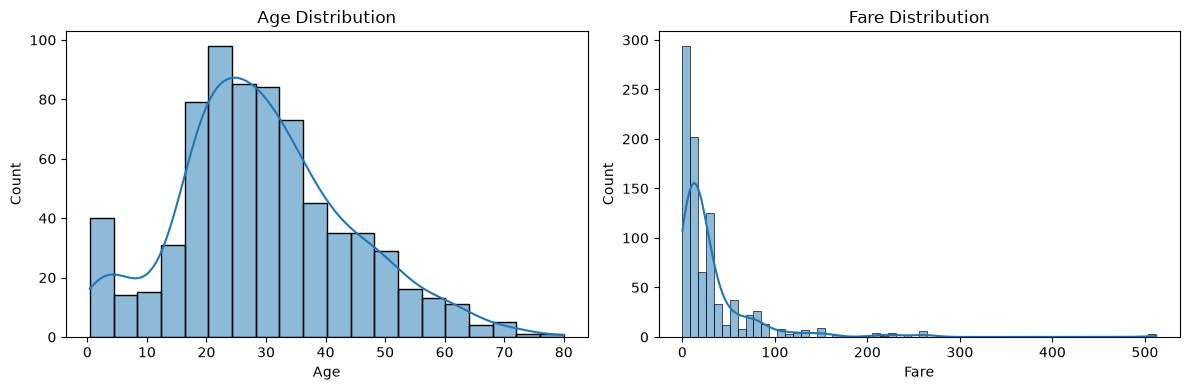

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Age"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Fare"], kde=True, ax=axes[1])
axes[1].set_title("Fare Distribution")

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

### Concept

Correlation analysis measures the strength and direction of linear relationships between numerical variables.

### Example

A positive correlation means two variables tend to increase together, while a negative correlation means one tends to decrease as the other increases.

### Interpretation

Correlation values close to zero indicate a weak linear relationship.

### Insight

Correlation helps identify potentially related features and possible feature redundancy.

### AI/ML Relevance

Correlation analysis can support feature selection and help identify potential multicollinearity.

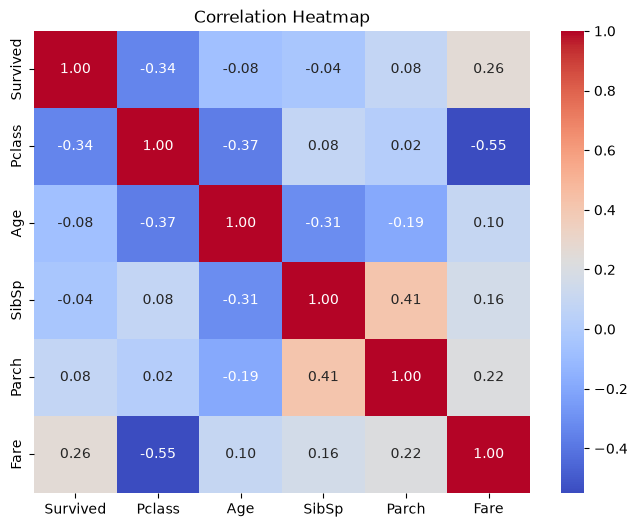

In [11]:
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 10. Meaningful Visualizations

### Concept

Visualizations make important patterns easier to understand and communicate.

### Example

A count plot can show survival differences across passenger classes, while a box plot can show fare variation.

### Interpretation

Each visualization should answer a specific question about the data.

### Insight

Visualizations can reveal patterns that may not be immediately visible from numerical summaries.

### AI/ML Relevance

Visual analysis helps identify useful features, outliers, relationships, and potential preprocessing requirements.

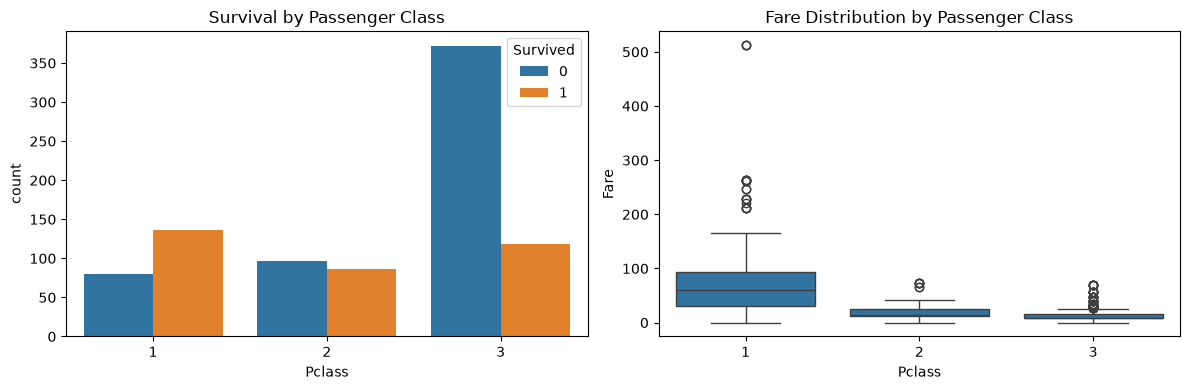

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[0])
axes[0].set_title("Survival by Passenger Class")

sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[1])
axes[1].set_title("Fare Distribution by Passenger Class")

plt.tight_layout()
plt.show()

## 11. Important Patterns

### Concept

Important patterns are meaningful observations obtained by combining statistical analysis and visualizations.

### Example

A higher survival rate for one passenger group compared with another represents an important pattern.

### Interpretation

Patterns help move the analysis from simply describing the data to understanding relationships.

### Insight

The Titanic dataset shows meaningful differences in survival across passenger characteristics such as sex and passenger class.

### AI/ML Relevance

Important patterns can help identify useful predictive features and possible feature interactions.

In [13]:
print("Survival Rate by Sex:")
print((df.groupby("Sex")["Survived"].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby("Pclass")["Survived"].mean() * 100).round(2))

Survival Rate by Sex:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


## 12. Business Insights

### Concept

Business insights convert observations from EDA into meaningful conclusions.

### Example

Instead of only saying that survival differs by passenger class, we can conclude that passenger class appears to be an important passenger segment associated with different survival outcomes.

### Interpretation

Business insights explain what the observed pattern means in a practical context.

### Insight

The analysis suggests that survival was associated with multiple passenger characteristics rather than a single factor.

Important segments include:

- Male and female passengers
- Different passenger classes
- Different age groups
- Passengers travelling alone or with family

### AI/ML Relevance

These insights help identify useful features and possible feature engineering opportunities for predictive modeling.

In [14]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("Average Family Size:", round(df["FamilySize"].mean(), 2))

print("\nSurvival Rate by Family Size:")
print((df.groupby("FamilySize")["Survived"].mean() * 100).round(2))

Average Family Size: 1.9

Survival Rate by Family Size:
FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64


## 13. Potential Data Problems

### Concept

Potential data problems are issues identified during EDA that may affect future Machine Learning analysis.

### Identified Problems

The dataset contains areas that may require attention:

- Missing values
- Potential outliers
- Categorical features requiring encoding
- Numerical features with different scales
- Skewed distributions
- Identifier-like or high-cardinality features
- Possible feature engineering opportunities

### Interpretation

These problems should be documented before making preprocessing decisions.

### Insight

EDA helps us identify what needs attention before modifying the original dataset.

### AI/ML Relevance

Understanding data problems first helps make preprocessing more systematic and avoids unnecessary changes.

In [15]:
print("Unique Values in Potential Identifier-Like Columns:")

for col in ["Name", "Ticket", "Cabin"]:
    print(f"{col}: {df[col].nunique()} unique values")

Unique Values in Potential Identifier-Like Columns:
Name: 891 unique values
Ticket: 681 unique values
Cabin: 147 unique values


## 14. Recommendations for the Next Preprocessing Stage

### Concept

Recommendations are proposed actions based on the problems identified during EDA.

### Recommended Next Steps

1. Investigate suitable missing-value treatment methods.
2. Review potential outliers before deciding on treatment.
3. Encode categorical variables.
4. Consider scaling numerical features where required.
5. Investigate transformations for highly skewed features.
6. Explore feature engineering opportunities.
7. Review data types before model preparation.
8. Evaluate identifier-like or high-cardinality columns carefully.

### Interpretation

These recommendations are based on the findings of the EDA.

### Insight

The correct preprocessing strategy should depend on the nature of each feature and the requirements of the selected Machine Learning model.

### AI/ML Relevance

Proper preprocessing can improve data quality and help build more reliable Machine Learning models.

Complete preprocessing is not performed in this notebook.

In [16]:
recommendations = [
    "Investigate missing-value treatment",
    "Review potential outliers",
    "Encode categorical variables",
    "Consider numerical feature scaling",
    "Review skewed feature transformations",
    "Explore feature engineering",
    "Review data types",
    "Evaluate identifier-like columns"
]

for i, item in enumerate(recommendations, start=1):
    print(f"{i}. {item}")

1. Investigate missing-value treatment
2. Review potential outliers
3. Encode categorical variables
4. Consider numerical feature scaling
5. Review skewed feature transformations
6. Explore feature engineering
7. Review data types
8. Evaluate identifier-like columns


# Final Conclusion

This EDA Mini Challenge demonstrated an independent Exploratory Data Analysis workflow using the Titanic dataset.

The analysis included:

- Loading and understanding the dataset
- Inspecting structure and data types
- Identifying missing values and duplicates
- Analyzing numerical and categorical features
- Detecting potential outliers
- Analyzing feature distributions
- Examining correlations and relationships
- Creating meaningful visualizations
- Identifying important patterns
- Writing business insights
- Recommending the next preprocessing steps

The analysis showed that EDA is not only about creating graphs or calculating statistics. The main objective is to understand the dataset, identify important patterns and problems, and make informed decisions before preprocessing and Machine Learning.

The next stage should focus on preprocessing the identified data issues in a systematic way.